In [1]:
import sys
sys.path.append('../src')

import numpy as np
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from hsgp1d import diag_spd_se, hsgp_basis, hsgp_se
import arviz as az

rng_key = random.PRNGKey(42)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid', palette='deep')

Generate a simple synthetic dataset.

In [2]:
def generate_synthetic_data(rng_key, start, stop: float, num, scale):
  x = jnp.linspace(start=start, stop=stop, num=num)
  y = jnp.sin(4 * jnp.pi * x) + jnp.sin(7 * jnp.pi * x)
  y_obs = y + scale * random.normal(rng_key, shape=(num,))
  return x, y, y_obs

n_train = 80
n_test = 100
scale = 0.3

rng_key, rng_subkey = random.split(rng_key)
x_train, y_train, y_obs_train = generate_synthetic_data(
  rng_subkey, 0, 1, n_train, scale
)

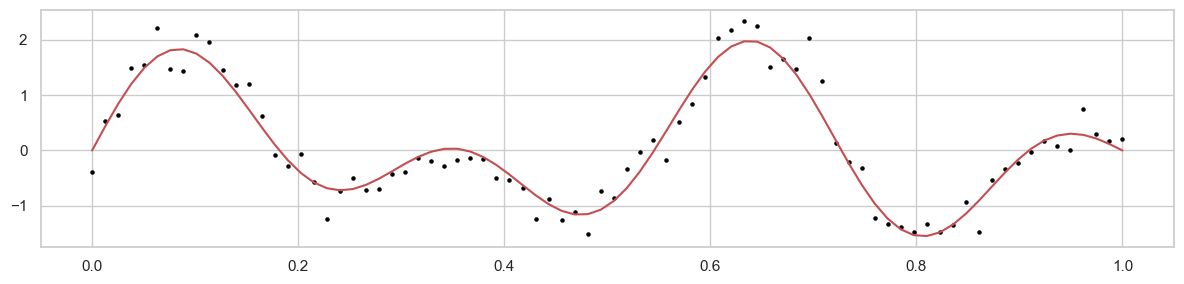

In [3]:
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(x_train, y_train, c='r')
ax.scatter(x_train, y_obs_train, c='black', s=5)

plt.tight_layout()
plt.show()

Define the NumPyro model

In [4]:
def model(x, L, M, y=None):
  X = hsgp_basis(x, L, M)

  alpha = numpyro.sample('alpha', dist.InverseGamma(5, 5))
  ell = numpyro.sample('ell', dist.InverseGamma(5, 5))
  z = numpyro.sample('z', dist.Normal(0, 1).expand([M]))
  sigma = numpyro.sample('sigma', dist.HalfCauchy(1))

  f = hsgp_se(z, X, alpha, ell, L, M)
  numpyro.sample('y', dist.Normal(f, sigma), obs=y)

Run the MCMC sampling.

In [5]:
sampler = NUTS(model)
mcmc = MCMC(sampler, num_warmup=500, num_samples=1000, num_chains=2)

train_mean = x_train.mean()
x_train_centered = x_train - train_mean

mcmc.run(rng_key, x_train_centered, 1.5, 30, y_obs_train)

/var/folders/fc/szc97hhx4sgg1mzfl9bt0n240000gn/T/ipykernel_95306/855210135.py:2: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=500, num_samples=1000, num_chains=2)
sample: 100%|██████████| 1500/1500 [00:04<00:00, 314.73it/s, 255 steps of size 1.99e-02. acc. prob=0.87]


Extract posterior summaries.

In [6]:
idata = az.from_numpyro(mcmc)

az.summary(
  data=idata,
  var_names=['alpha', 'ell', 'sigma']
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.561,1.178,1.705,5.841,0.039,0.027,905.0,1106.0,1.00
ell,0.137,0.012,0.116,0.158,0.000,0.000,1303.0,1365.0,1.01
sigma,0.283,0.025,0.239,0.334,0.001,0.000,2053.0,1326.0,1.00


Sample from the posterior predictive.

In [7]:
predictive = Predictive(model, mcmc.get_samples())
posterior_predictive = predictive(rng_subkey, x_train_centered, 1.5, 30)

idata.extend(az.from_numpyro(posterior_predictive=posterior_predictive))

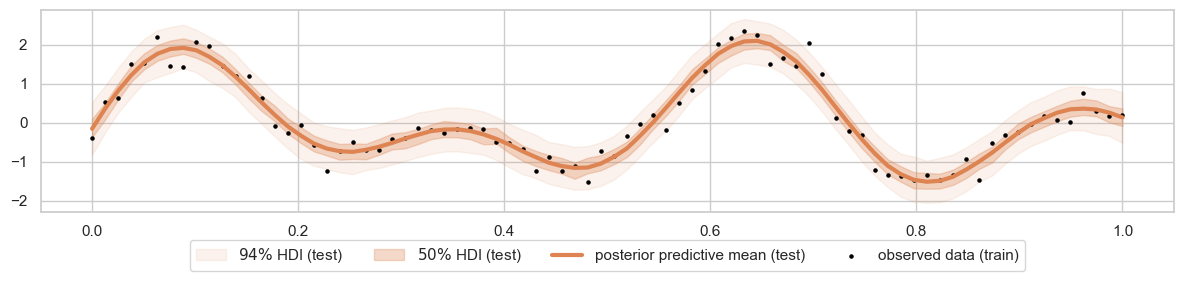

In [8]:
fig, ax = plt.subplots(figsize=(12,3))

az.plot_hdi(
    x_train,
    idata.posterior_predictive['y'],
    hdi_prob=0.94,
    color='C1',
    smooth=False,
    fill_kwargs={'alpha': 0.1, 'label': '$94\\%$ HDI (test)'},
    ax=ax,
)
az.plot_hdi(
    x_train,
    idata.posterior_predictive['y'],
    hdi_prob=0.5,
    color='C1',
    smooth=False,
    fill_kwargs={'alpha': 0.3, 'label': '$50\\%$ HDI (test)'},
    ax=ax,
)
ax.plot(
    x_train,
    idata.posterior_predictive['y'].mean(dim=('chain', 'draw')),
    color='C1',
    linewidth=3,
    label='posterior predictive mean (test)',
)
ax.scatter(x_train, y_obs_train, color='black', s=5, label='observed data (train)')
ax.legend(loc = 'upper center', bbox_to_anchor = (0.5, -0.1), ncol=4)

fig.tight_layout()
plt.show()